Generalised Profiling Tutorial 

Lotka-Volterra Predator-Prey System

Alexander Johnston
Queensland University of Technology
a44.johnston@qut.edu.au

In [12]:
using Plots, DelimitedFiles, DifferentialEquations, SparseArrays, Interpolations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Plots.PlotMeasures, LinearAlgebra
gr()

plot_font = "Computer Modern"
default(fontfamily=plot_font,linewidth=1,framestyle=:box,label=nothing,grid=true)

#Model parameters
alpha = 1;
beta = 1;

#Initial conditions
x0 = 1;
y0 = 0.5;

a = [alpha, beta];
ic = [x0, y0];

#Number of synthetic data points
N_data = 41;
N_t = 500;

t_start = 0;
t_end = 25
t = LinRange(t_start, t_end, N_data);

tt = LinRange(t_start, t_end, N_t);

#Standard deviation of additive Gaussian noise used to generate the synthetic data
sigma=0.1; 



Creating synthetic data sets.

In [13]:
#Create synthetic data for the Lotka-Volterra predator-prey model.

#Lotka-Volterra predator-prey equations
function Lotka_Volterra!(du,u,a,t)
alpha = a[1];
beta = a[2];
du[1]=alpha*u[1] - u[1]*u[2]; 
du[2]=beta*u[1]*u[2] - u[2];
end

function odesolver(t,ic,a)
tspan=(0.0,maximum(t))
prob=ODEProblem(Lotka_Volterra!,ic,tspan, a)
alg=Tsit5()
sol=solve(prob,alg,saveat=t);
return sol
end

ic=[x0, y0]
sol = odesolver(t,ic,a)
    
#Create stochastic data using additive Gaussian noise applied at each data point for the true solution

dist=Normal(0,sigma);

#x_data_sample = zeros(length(x));
#y_data_sample = zeros(length(x));

#for (i, x_model_i) in enumerate(x)
#    x_data_sample[i] = x_model_i + rand(dist)
#end

#for (i, y_model_i) in enumerate(y)
#    y_data_sample[i] = y_model_i + rand(dist)
#end

t_data = t;

x = readdlm("Lotka_Volterra_x_data")
y = readdlm("Lotka_Volterra_y_data")

x_data = x;
y_data = y;

data = vcat(x_data, y_data);


Defining the log-likelihood function and determining the maximum likelihood estimate (MLE).

In [14]:
function loglhood(data,ic,a)
    sol = odesolver(t,ic,a)
    x = sol[1,:];
    y = sol[2,:];
    y1 = vcat(x, y);
    e = 0;
    dist = Normal(0,sigma);
    e = loglikelihood(dist, data-y1) 
    return sum(e)
end

function Optimise(fun,θ₀,lb,ub)    
    tomax=(θ,∂θ)->fun(θ)
    opt=NLopt.Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = NLopt.optimize(opt,θ₀)
    return res[[2,1]]
end 

function funmle(a)
return loglhood(data,ic,a)
end

alphamin= 0.8;
alphamax = 1.3;
betamin=0.8;
betamax=1.3;
c1_0min = 1;
c1_0max = 1;
c2_0min = 0.5;
c2_0max = 0.5;

θG = [0.9, 0.85, 1, 0.5]

lb = [alphamin, betamin, c1_0min, c2_0min];
ub = [alphamax, betamax, c1_0max, c2_0min];

(xopt,fopt)=Optimise(funmle,θG,lb,ub)
alphamle=xopt[1]
betamle=xopt[2]
c1_0mle = xopt[3]
c2_0mle = xopt[4]

0.5

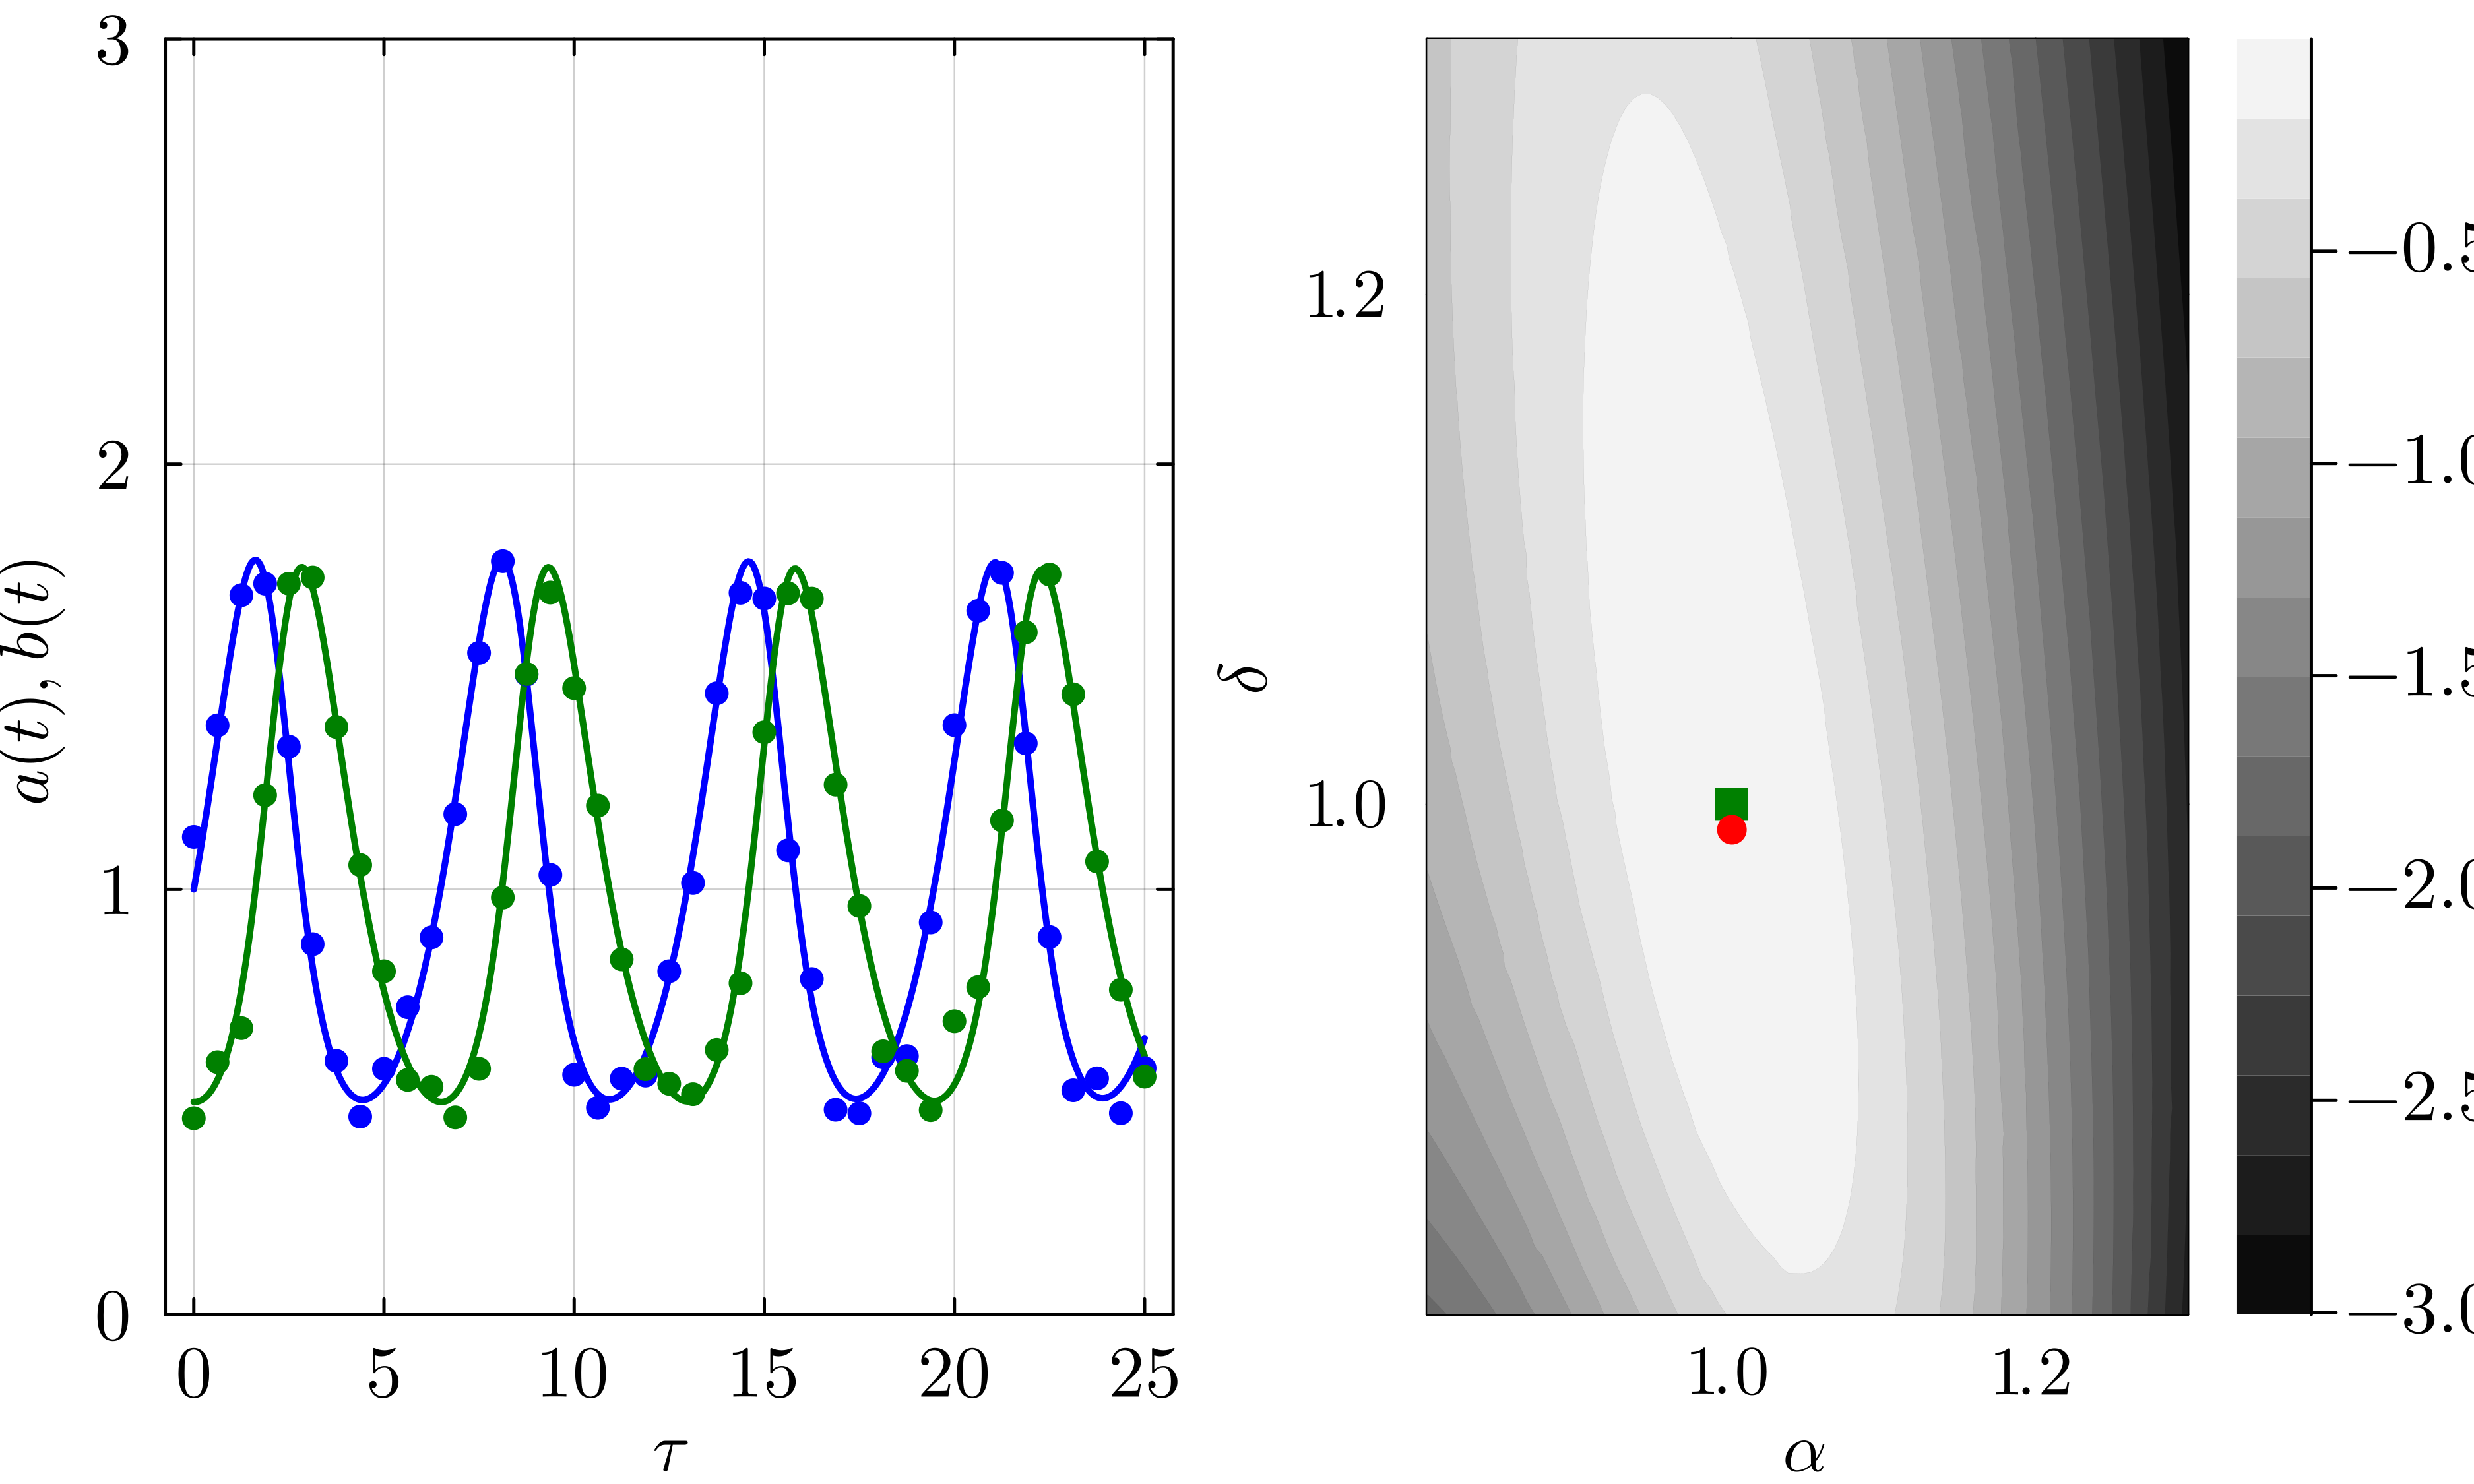

In [15]:
sol = odesolver(tt,ic,[alphamle, betamle])
x1 = sol[1,:];
y1 = sol[2,:];

p1 = plot(tt, x1, color = "blue",lw=2, label=false)
p1 = plot!(tt, y1, color = "green", lw=2, label=false)
p1 = scatter!(t, x, color = "blue", mc=:blue,msc=:blue,label=false,msw=0,ms=4, xlabel = L"\tau", ylabel = L"a(t), b(t)", ylims = (0,3), xguidefontsize=14, yguidefontsize=14, xtickfontsize=14, ytickfontsize=14)
p1 = scatter!(t, y, color = "green", mc=:green,msc=:green,label=false,msw=0,ms=4) 

Q=100
alphalist=LinRange(alphamin,alphamax,Q);
betalist=LinRange(betamin,betamax,Q);
df=2
llstar=-quantile(Chisq(df),0.95)/2
p2=contourf(alphalist, betalist ,(alphalist, betalist)->(funmle([alphalist, betalist])-fopt)/1000,lw=0,xlabel=L"\alpha",ylabel=L"\delta",c=:grays,colorbar=:true,colorbarlabel=L"\bar{\ell}")
p2=scatter!([alpha],[beta],markersize=3,markershape=:square,markercolor=:green,msw=0,ms=5)
p2=scatter!([alphamle],[betamle],markersize=3,markershape=:circle,markercolor=:red,msw=0,ms=5)
#p2=contour!(alphalist,betalist,(alphalist,betalist)->funmle([alphalist,betalist])-fopt,levels=[llstar],lw=4,c=:gold,legend=false)
p2=plot!(xlims=(alphamin,alphamax),xticks=([1, 1.2],[L"1.0", L"1.2"]),ylims=(alphamin,betamax),yticks=([1, 1.2],[L"1.0", L"1.2"]))
p2=plot!(xguidefontsize=14, yguidefontsize=14, xtickfontsize=14, ytickfontsize=14)
p3=plot(p1,p2,layout=(1,2), size = (750, 450), dpi = 500)
plot(p3)

In [16]:
#Profile for alpha

import Base: +, -, *

function univariatealpha(alpha)
    a=zeros(1)    
    function funalpha(a)
    return loglhood(data, ic, [alpha, a[1]])
    end
    θG=[betamle]
    lb=[0.99] 
    ub=[1.01] 
    (xopt,fopt)=Optimise(funalpha,θG,lb,ub)
    return fopt,xopt
    end 

#Take a grid of M points to plot the univariate profile likelihood
M=50;
alpharange=LinRange(0.99,1.01,M)
ff=zeros(M)
for i in 1:M
    ff[i]=univariatealpha(alpharange[i])[1]
end


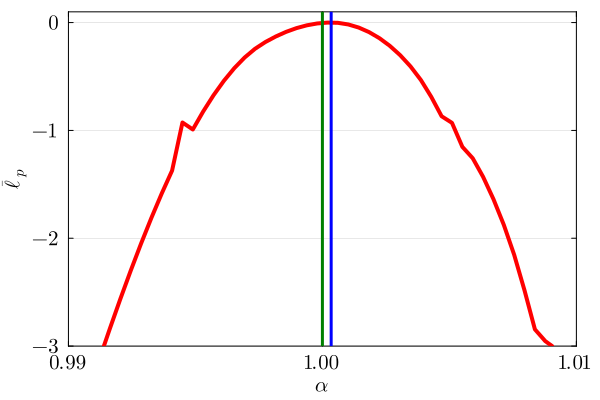

In [17]:
sp3=Spline1D(alpharange,ff.-maximum(ff),w=ones(length(alpharange)),k=3,bc="nearest",s=1/100);
yy=Dierckx.evaluate(sp3,alpharange);
alpha_plot=plot(alpharange,yy,lw=4,lc=:red,ylims=(-3,0.1),size = (300, 300));
alpha_plot=plot(alpharange,ff.-maximum(ff),lw=4,lc=:red,xlims=(0.99, 1.01));
alpha_plot=vline!([alphamle],legend=false,xlabel=L"\alpha",lw=3,color=:blue);
alpha_plot=vline!([alpha],legend=false,xlabel=L"\alpha",lw=3,color=:green);
#alpha_plot=plot!(xlims=(alphamin,alphamax));
alpha_plot=plot!(xticks=([0.99, 1, 1.01],[L"0.99", L"1.00", L"1.01"]), ylims=(-3,0.1),yticks=([-3,-2,-1,0],[L"-3", L"-2", L"-1",L"0"]));
alpha_plot=plot!(ylabel = L"\bar{\ell}_{p}", xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14, right_margin=4mm)

In [18]:
#Profile for beta

function univariatebeta(beta)
    a=zeros(1)    
    function funbeta(a)
    return loglhood(data, ic, [a[1], beta])
    end
    θG=[alphamle]
    lb=[0.95] 
    ub=[1.05] 
    (xopt,fopt)=Optimise(funbeta,θG,lb,ub)
    return fopt,xopt
    end 

#Take a grid of M points to plot the univariate profile likelihood
M=50;
betarange=LinRange(0.95,1.05,M)
ff=zeros(M)
for i in 1:M
    ff[i]=univariatebeta(betarange[i])[1]
end


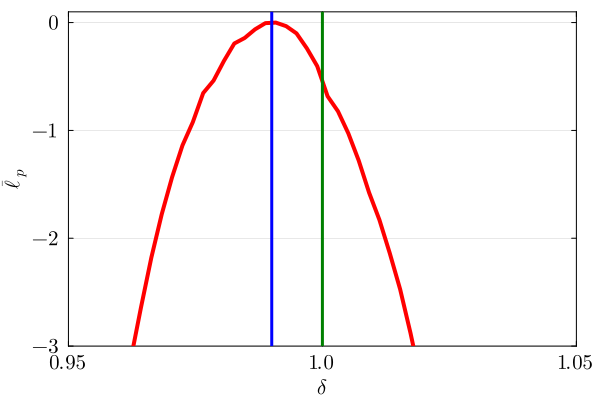

In [19]:
sp3=Spline1D(betarange,ff.-maximum(ff),w=ones(length(betarange)),k=3,bc="nearest",s=1/100);
yy=Dierckx.evaluate(sp3,betarange);
beta_plot=plot(betarange,yy,lw=4,lc=:red,ylims=(-3,0.1),size = (300, 300));
beta_plot=plot(betarange,ff.-maximum(ff),lw=4,lc=:red,xlims=(0.95, 1.05));
beta_plot=vline!([betamle],legend=false,xlabel=L"\delta",lw=3,color=:blue);
beta_plot=vline!([beta],legend=false,xlabel=L"\delta",lw=3,color=:green);
#beta_plot=plot!(xlims=(betamin,betamax));
beta_plot=plot!(xticks=([0.95, 1, 1.05],[L"0.95", L"1.0", L"1.05"]), ylims=(-3,0.1),yticks=([-3,-2,-1,0],[L"-3", L"-2", L"-1",L"0"]));
beta_plot=plot!(ylabel = L"\bar{\ell}_{p}", xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14, right_margin=4mm)

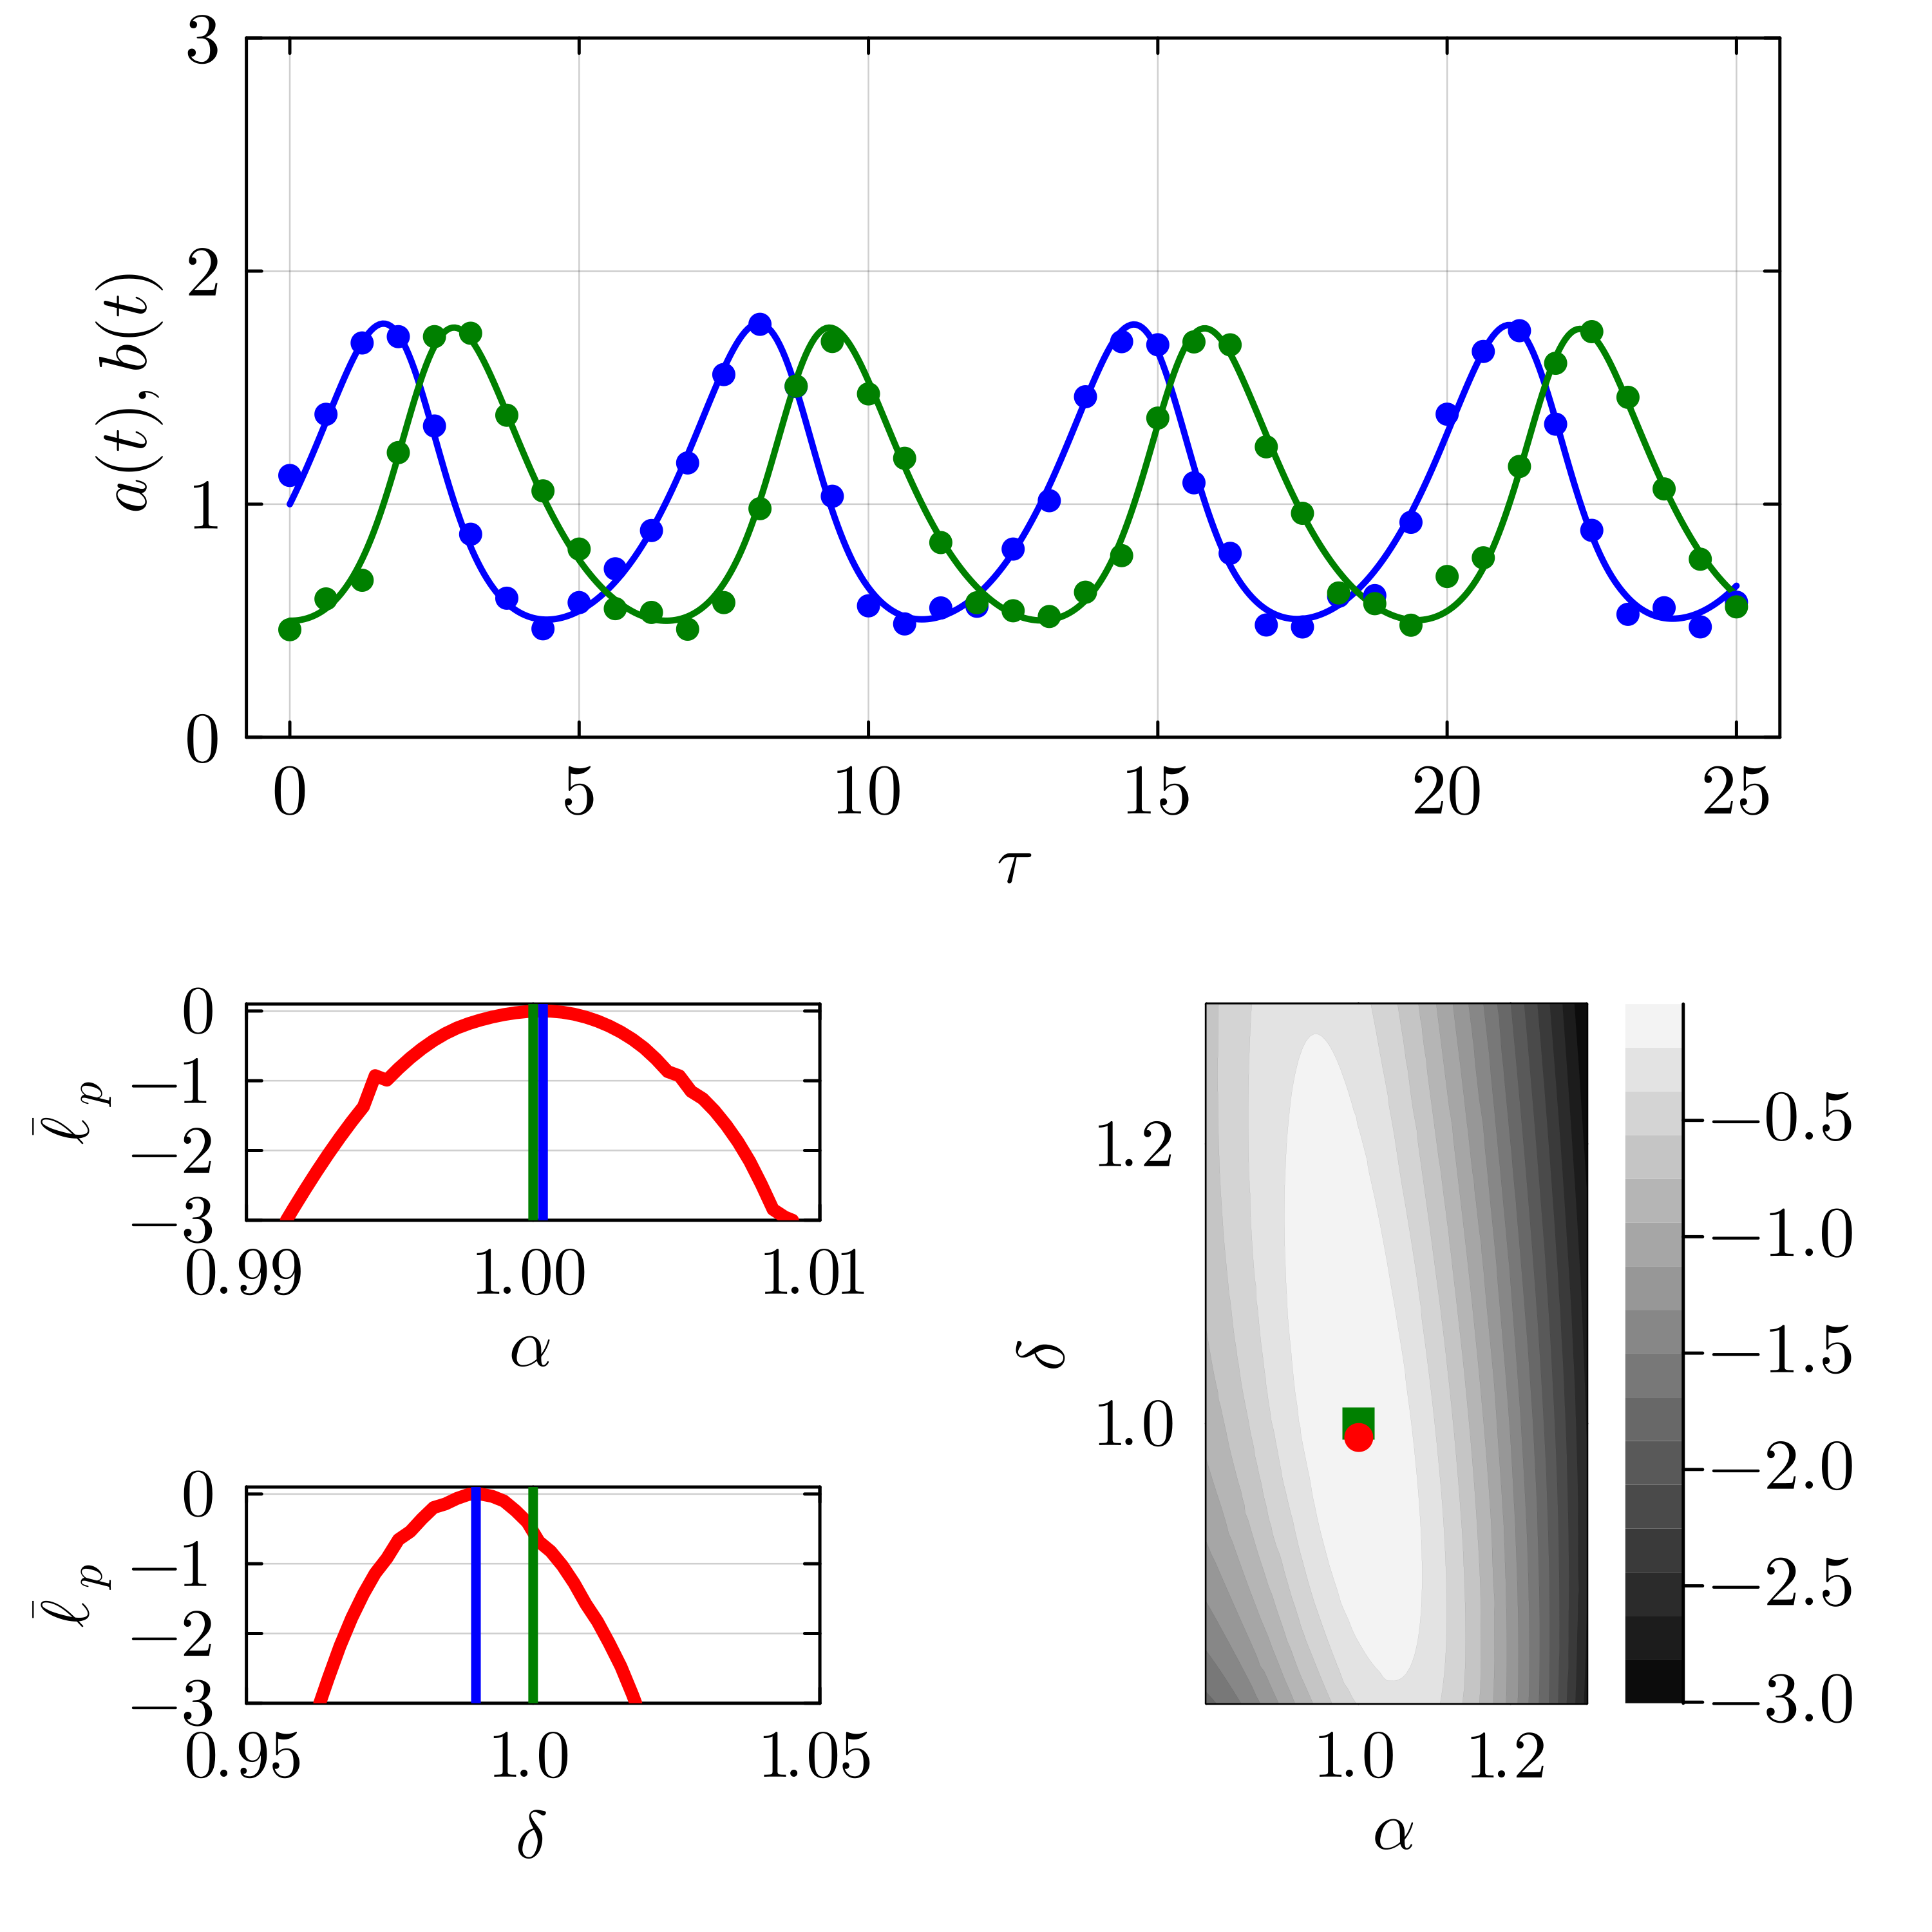

In [20]:
p4=plot(alpha_plot, beta_plot,layout=(2,1))
p5 = plot(p4, p2, layout=(1,2))
p3=plot(p1,p5,layout=(2,1), size = (600, 600), dpi = 500, right_margin=10mm)